Using device: cpu
✓ Model loaded successfully

GRAD-CAM: Tumor Cases

Processing 1/3: y126.jpg


c:\Users\mohdf\OneDrive - Singapore Institute Of Technology\Capstone\Project\venv\Lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved to gradcam_yes_1.png


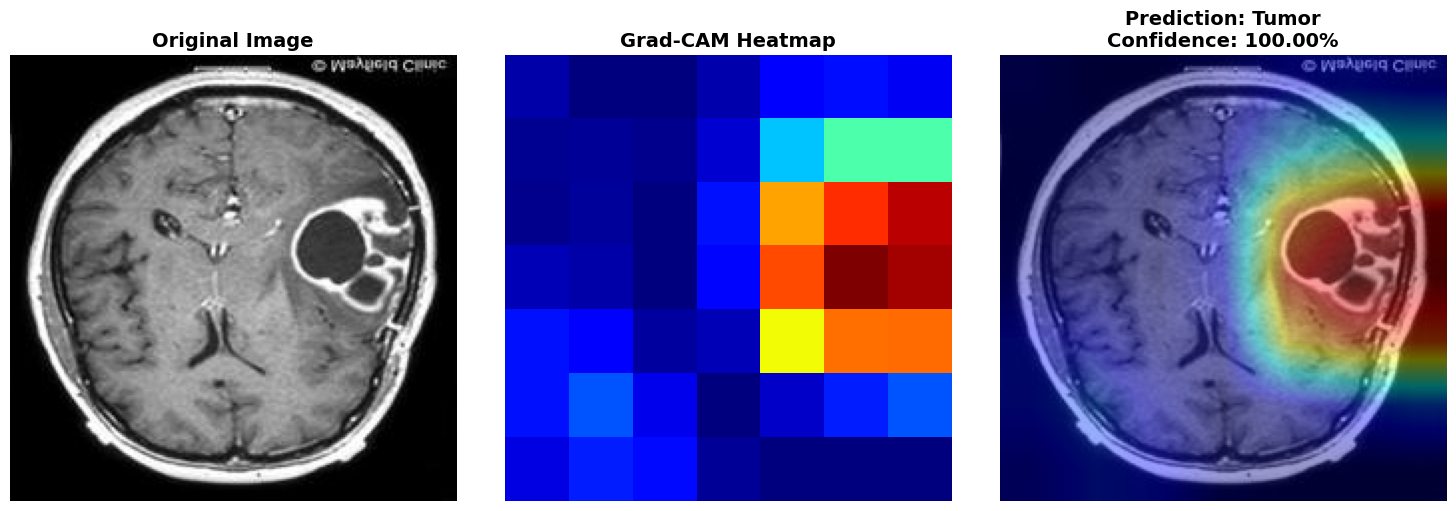


Processing 2/3: y1058.jpg
Saved to gradcam_yes_2.png


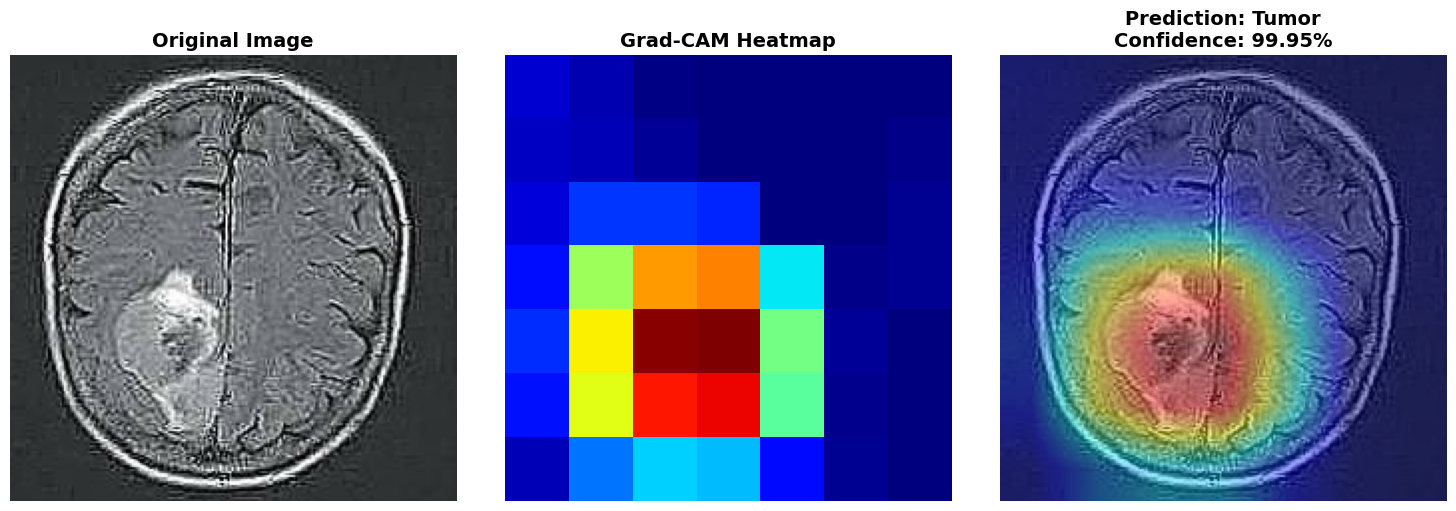


Processing 3/3: y237.jpg
Saved to gradcam_yes_3.png


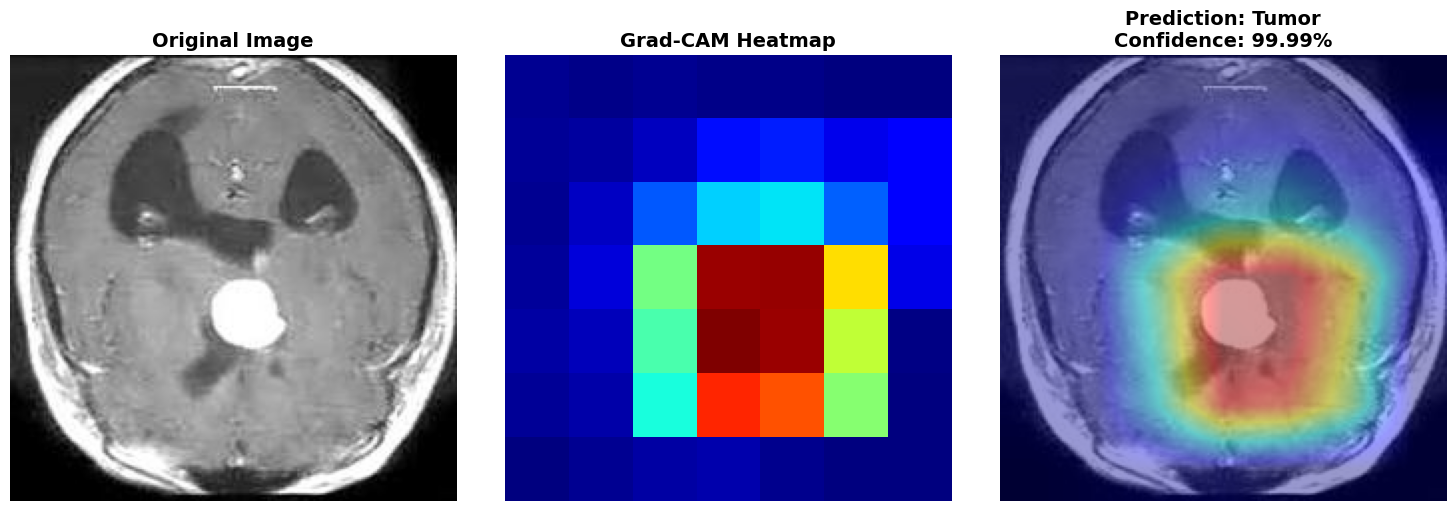


GRAD-CAM: No Tumor Cases

Processing 1/3: no1259.jpg
Saved to gradcam_no_1.png


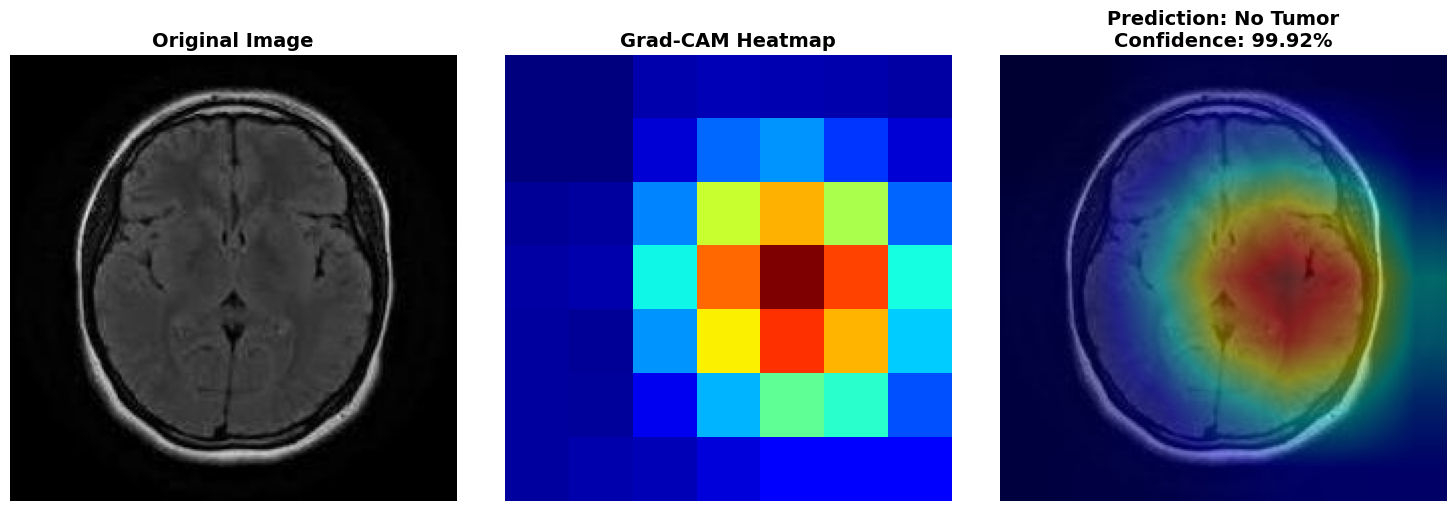


Processing 2/3: no106.jpg
Saved to gradcam_no_2.png


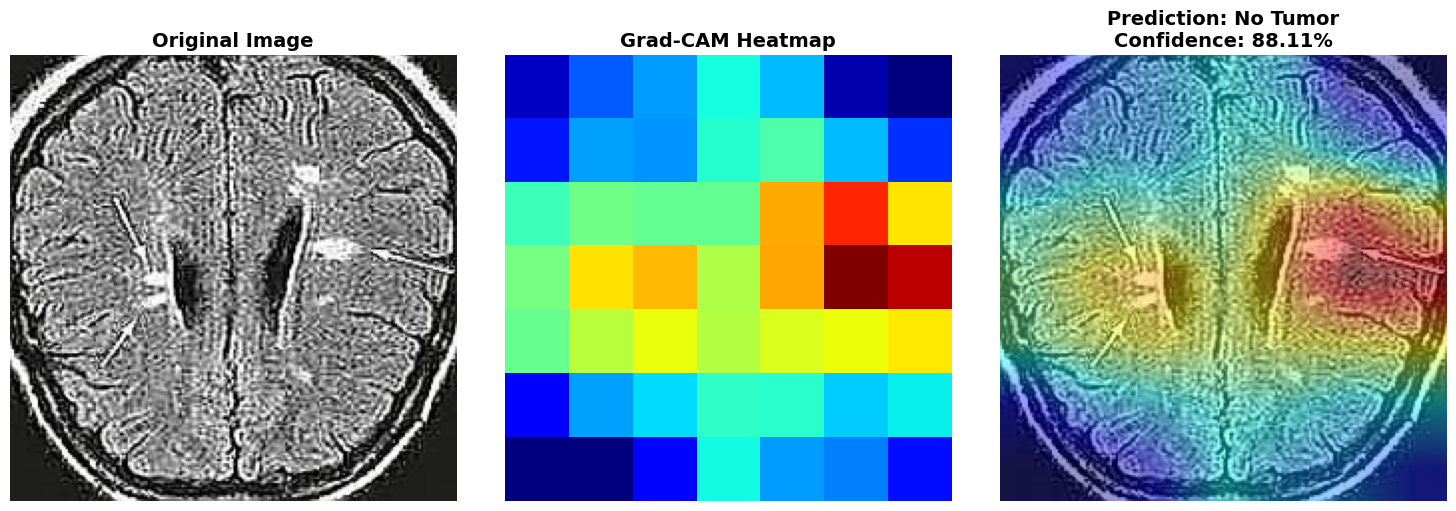


Processing 3/3: no237.jpg
Saved to gradcam_no_3.png


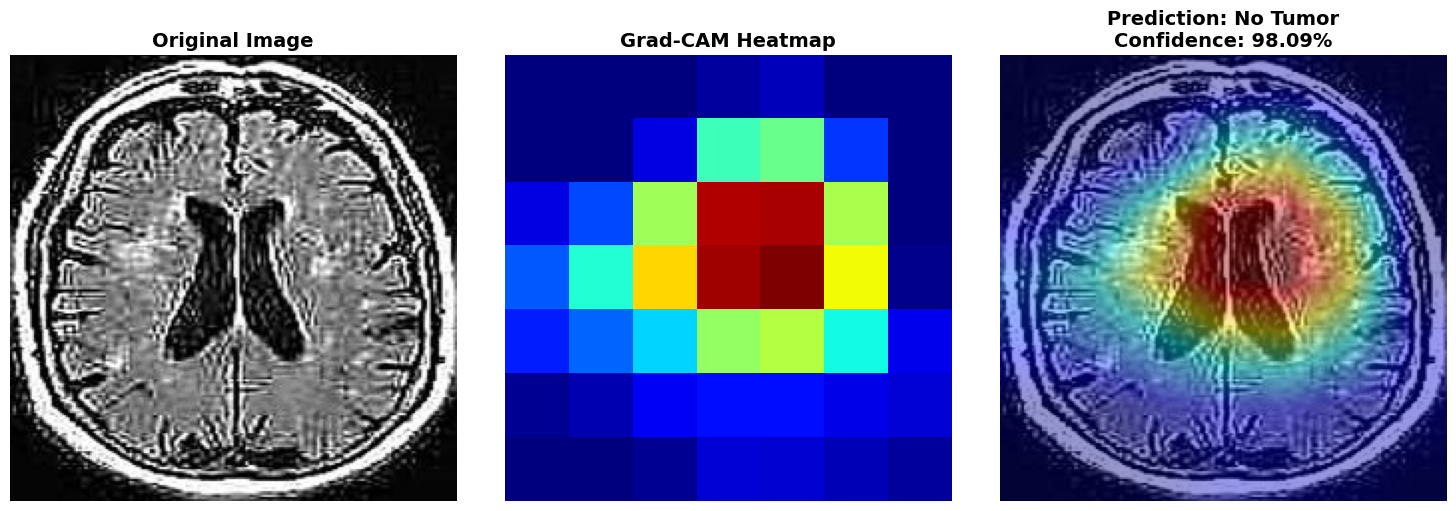


SUMMARY

Tumor Cases:
  y126.jpg: Tumor (100.00%)
  y1058.jpg: Tumor (99.95%)
  y237.jpg: Tumor (99.99%)

No Tumor Cases:
  no1259.jpg: No Tumor (99.92%)
  no106.jpg: No Tumor (88.11%)
  no237.jpg: No Tumor (98.09%)

✓ Grad-CAM analysis complete!
  Check the generated 'gradcam_*.png' files


In [2]:
# ==================== Grad-CAM for PyTorch ResNet50 ====================
# Adapted for brain tumor classification

import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==================== Load Model ====================

# Load ResNet50 architecture
resnet50 = models.resnet50(weights=None)
num_features = resnet50.fc.in_features
resnet50.fc = torch.nn.Linear(num_features, 2)  # Binary classification
resnet50 = resnet50.to(device)

# Load trained weights
checkpoint = torch.load("resnet50_best.pth", map_location=device)
resnet50.load_state_dict(checkpoint)
resnet50.eval()

print("✓ Model loaded successfully")

# ==================== Grad-CAM Implementation ====================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_heatmap(self, input_image, class_idx=None):
        # Forward pass
        output = self.model(input_image)
        
        # Get predicted class if not specified
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        class_score = output[:, class_idx]
        class_score.backward()
        
        # Generate heatmap
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight activations by gradients
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        # Average over channels
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        
        # ReLU on heatmap
        heatmap = F.relu(heatmap)
        
        # Normalize between 0 and 1
        heatmap /= torch.max(heatmap)
        
        return heatmap.cpu().numpy(), class_idx

# ==================== Image Processing ====================

def load_and_preprocess_image(img_path, img_size=(224, 224)):
    """Load and preprocess image for ResNet50"""
    # ImageNet normalization (same as training)
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    
    return img_tensor, img

def superimpose_heatmap(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """Overlay heatmap on original image"""
    # Load original image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize heatmap to match image size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convert heatmap to RGB
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Superimpose
    superimposed = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)
    
    return superimposed

# ==================== Visualization ====================

def visualize_gradcam(img_path, heatmap, prediction, confidence, save_path=None):
    """Create comprehensive Grad-CAM visualization"""
    # Load original image
    original_img = Image.open(img_path).convert('RGB')
    
    # Create superimposed image
    superimposed = superimpose_heatmap(img_path, heatmap, alpha=0.4)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Heatmap only
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Superimposed
    axes[2].imshow(superimposed)
    pred_label = 'Tumor' if prediction == 1 else 'No Tumor'
    axes[2].set_title(f'Prediction: {pred_label}\nConfidence: {confidence:.2%}', 
                     fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()

# ==================== Process Multiple Test Images ====================

def process_test_images(test_dir, num_samples=5, class_label='yes'):
    """Process random test images from specified class"""
    # Get images
    class_dir = Path(test_dir) / class_label
    image_paths = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
    
    if len(image_paths) == 0:
        print(f"No images found in {class_dir}")
        return
    
    # Randomly sample
    import random
    random.seed(42)
    sampled_paths = random.sample(image_paths, min(num_samples, len(image_paths)))
    
    # Initialize Grad-CAM (target last conv layer in ResNet50)
    target_layer = resnet50.layer4[-1]  # Last bottleneck block
    gradcam = GradCAM(resnet50, target_layer)
    
    # Process each image
    results = []
    for idx, img_path in enumerate(sampled_paths):
        print(f"\nProcessing {idx+1}/{len(sampled_paths)}: {img_path.name}")
        
        # Load and preprocess
        img_tensor, original_img = load_and_preprocess_image(img_path)
        img_tensor = img_tensor.to(device)
        
        # Get prediction
        with torch.no_grad():
            output = resnet50(img_tensor)
            probs = F.softmax(output, dim=1)
            predicted_class = output.argmax(dim=1).item()
            confidence = probs[0, predicted_class].item()
        
        # Generate Grad-CAM
        heatmap, pred_class = gradcam.generate_heatmap(img_tensor, class_idx=predicted_class)
        
        # Visualize
        save_path = f"gradcam_{class_label}_{idx+1}.png"
        visualize_gradcam(img_path, heatmap, predicted_class, confidence, save_path)
        
        results.append({
            'image': img_path.name,
            'true_label': class_label,
            'predicted_class': 'Tumor' if predicted_class == 1 else 'No Tumor',
            'confidence': confidence,
            'heatmap': heatmap
        })
    
    return results

# ==================== Run Grad-CAM Analysis ====================

test_dir = "dataset_processed/test"

print("\n" + "="*60)
print("GRAD-CAM: Tumor Cases")
print("="*60)
tumor_results = process_test_images(test_dir, num_samples=3, class_label='yes')

print("\n" + "="*60)
print("GRAD-CAM: No Tumor Cases")
print("="*60)
no_tumor_results = process_test_images(test_dir, num_samples=3, class_label='no')

# ==================== Summary Statistics ====================

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

if tumor_results:
    print("\nTumor Cases:")
    for r in tumor_results:
        print(f"  {r['image']}: {r['predicted_class']} ({r['confidence']:.2%})")

if no_tumor_results:
    print("\nNo Tumor Cases:")
    for r in no_tumor_results:
        print(f"  {r['image']}: {r['predicted_class']} ({r['confidence']:.2%})")

print("\n✓ Grad-CAM analysis complete!")
print("  Check the generated 'gradcam_*.png' files")